In [9]:
import tensorflow as tf
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mtcnn import MTCNN
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("dlib version:", dlib.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
dlib version: 20.0.0
All libraries imported successfully!


In [10]:
import os

# Dataset paths
DATASET_PATH = r"C:\Users\vp141\Downloads\FF_Dataset"

REAL_VIDEOS = os.path.join(DATASET_PATH, "original_sequences", "youtube", "c23", "videos")

FAKE_VIDEOS = {
    "Deepfakes": os.path.join(DATASET_PATH, "manipulated_sequences", "Deepfakes", "c23", "videos"),
    "Face2Face": os.path.join(DATASET_PATH, "manipulated_sequences", "Face2Face", "c23", "videos"),
    "FaceSwap": os.path.join(DATASET_PATH, "manipulated_sequences", "FaceSwap", "c23", "videos"),
    "NeuralTextures": os.path.join(DATASET_PATH, "manipulated_sequences", "NeuralTextures", "c23", "videos"),
}

# Verify paths exist
print("Real videos path exists:", os.path.exists(REAL_VIDEOS))
for name, path in FAKE_VIDEOS.items():
    print(f"{name} path exists:", os.path.exists(path))

# Count videos
real_count = len(os.listdir(REAL_VIDEOS))
print(f"\nReal videos: {real_count}")
for name, path in FAKE_VIDEOS.items():
    count = len(os.listdir(path))
    print(f"{name} videos: {count}")

Real videos path exists: True
Deepfakes path exists: True
Face2Face path exists: True
FaceSwap path exists: True
NeuralTextures path exists: True

Real videos: 50
Deepfakes videos: 68
Face2Face videos: 50
FaceSwap videos: 50
NeuralTextures videos: 50


In [5]:
# Get video lists - limit Deepfakes to 50 to keep total = 250
real_videos = sorted(os.listdir(REAL_VIDEOS))[:50]

fake_videos = {}
for name, path in FAKE_VIDEOS.items():
    if name == "Deepfakes":
        fake_videos[name] = sorted(os.listdir(path))[:50]  # limit to 50
    else:
        fake_videos[name] = sorted(os.listdir(path))

# Verify counts
print(f"Real videos: {len(real_videos)}")
for name, videos in fake_videos.items():
    print(f"{name} videos: {len(videos)}")

total_fake = sum(len(v) for v in fake_videos.values())
print(f"\nTotal fake videos: {total_fake}")
print(f"Total videos: {len(real_videos) + total_fake}")

Real videos: 50
Deepfakes videos: 50
Face2Face videos: 50
FaceSwap videos: 50
NeuralTextures videos: 50

Total fake videos: 200
Total videos: 250


In [16]:
# Create output folders
output_real = os.path.join(DATASET_PATH, "extracted_faces", "real")
output_fake = os.path.join(DATASET_PATH, "extracted_faces", "fake")

os.makedirs(output_real, exist_ok=True)
os.makedirs(output_fake, exist_ok=True)

print("Output folders created!")
print("Real faces folder:", output_real)
print("Fake faces folder:", output_fake)

Output folders created!
Real faces folder: C:\Users\vp141\Downloads\FF_Dataset\extracted_faces\real
Fake faces folder: C:\Users\vp141\Downloads\FF_Dataset\extracted_faces\fake


In [11]:
detector = MTCNN()

def align_face(image, left_eye, right_eye):
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))
    eye_center = (float((left_eye[0] + right_eye[0]) / 2),
                  float((left_eye[1] + right_eye[1]) / 2))
    M = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    aligned = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
    return aligned

def extract_faces_from_video(video_path, output_folder, video_name, label, max_frames=10):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, max_frames, dtype=int)
    saved = 0
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb)
        if results:
            face_data = results[0]
            x, y, w, h = face_data['box']
            x, y = max(0, x), max(0, y)
            keypoints = face_data['keypoints']
            left_eye = keypoints['left_eye']
            right_eye = keypoints['right_eye']
            aligned = align_face(rgb, left_eye, right_eye)
            face = aligned[y:y+h, x:x+w]
            if face.size == 0:
                continue
            face = cv2.resize(face, (224, 224))
            face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
            filename = f"{label}_{video_name}_frame{idx}.jpg"
            cv2.imwrite(os.path.join(output_folder, filename), face_bgr)
            saved += 1
    cap.release()
    return saved

# ✅ SKIP IF ALREADY EXTRACTED
real_count = len(os.listdir(output_real)) if os.path.exists(output_real) else 0
fake_count = len(os.listdir(output_fake)) if os.path.exists(output_fake) else 0

if real_count == 500 and fake_count == 2000:
    print(f"✅ Already extracted! Real: {real_count}, Fake: {fake_count} — Skipping!")
else:
    print("Extracting faces...")
    os.makedirs(output_real, exist_ok=True)
    os.makedirs(output_fake, exist_ok=True)
    total_real = 0
    for video in real_videos:
        video_path = os.path.join(REAL_VIDEOS, video)
        saved = extract_faces_from_video(video_path, output_real, video, "real")
        total_real += saved
    print(f"Real faces extracted: {total_real}")
    total_fake_faces = 0
    for manip_type, videos in fake_videos.items():
        for video in videos:
            video_path = os.path.join(FAKE_VIDEOS[manip_type], video)
            saved = extract_faces_from_video(video_path, output_fake, f"{manip_type}_{video}", "fake")
            total_fake_faces += saved
        print(f"{manip_type} done!")
    print(f"Total faces extracted: {total_real + total_fake_faces}")

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


✅ Already extracted! Real: 500, Fake: 2000 — Skipping!


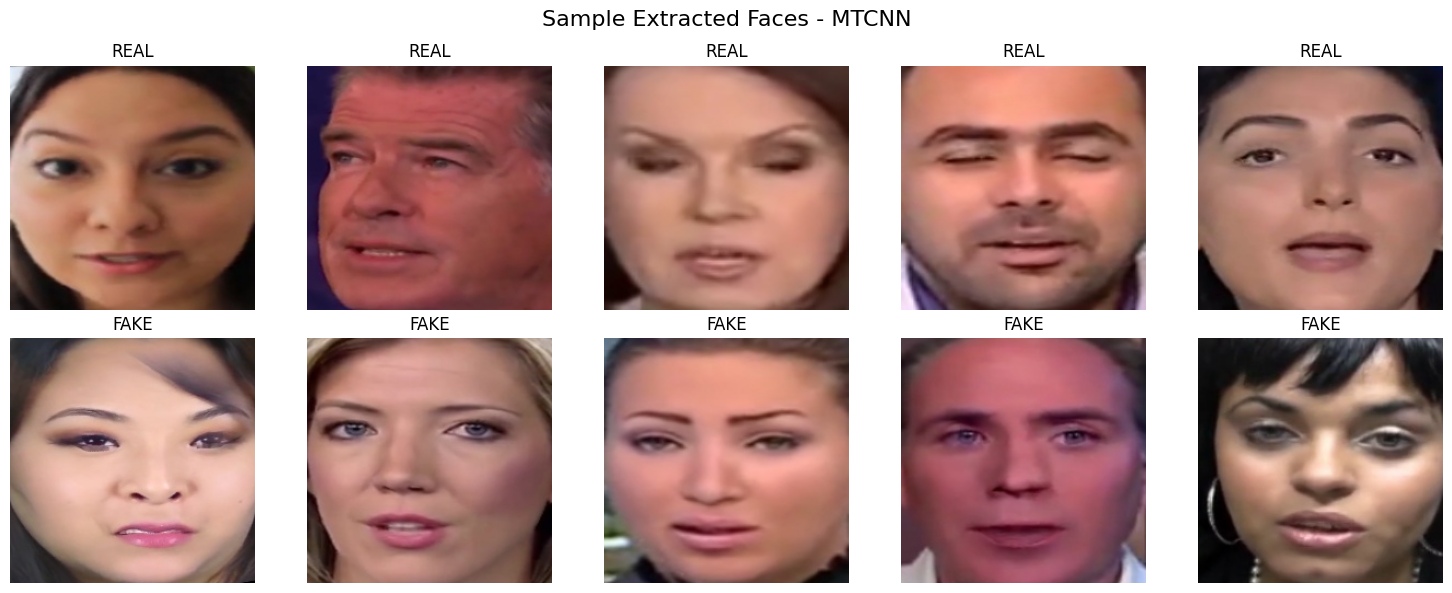

Image saved!


In [182]:
import random

real_images = os.listdir(output_real)
fake_images = os.listdir(output_fake)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Extracted Faces - MTCNN", fontsize=16)

# Show 5 real faces
for i in range(5):
    img_path = os.path.join(output_real, random.choice(real_images))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title("REAL")
    axes[0, i].axis("off")

# Show 5 fake faces
for i in range(5):
    img_path = os.path.join(output_fake, random.choice(fake_images))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title("FAKE")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "face_extraction_sample.png"), dpi=150)
plt.show()
print("Image saved!")

In [183]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pickle

def extract_fft_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))
    fft = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log(np.abs(fft_shift) + 1)
    return magnitude.flatten()

# ✅ SMART SKIP
if os.path.exists(os.path.join(DATASET_PATH, "svm_model.pkl")):
    print("✅ SVM already trained! Loading...")
    with open(os.path.join(DATASET_PATH, "svm_model.pkl"), "rb") as f:
        pca, svm_model, X_test_pca, y_test = pickle.load(f)
    print("Loaded!")
else:
    print("Extracting FFT features...")
    X_real, X_fake = [], []
    for img_file in os.listdir(output_real):
        X_real.append(extract_fft_features(os.path.join(output_real, img_file)))
    for img_file in os.listdir(output_fake):
        X_fake.append(extract_fft_features(os.path.join(output_fake, img_file)))

    # Balance dataset
    X_fake_balanced = X_fake[:len(X_real)]
    X = np.array(X_real + X_fake_balanced)
    y = np.array([0]*len(X_real) + [1]*len(X_fake_balanced))
    print(f"Balanced — Real: {len(X_real)}, Fake: {len(X_fake_balanced)}")

    # 70% train, 15% val, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    print("Reducing with PCA to 500 features...")
    pca = PCA(n_components=500, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    print("Training SVM...")
    svm_model = SVC(kernel='rbf', C=10, probability=True, random_state=42)
    svm_model.fit(X_train_pca, y_train)

    # Validate
    y_val_pred = svm_model.predict(X_val_pca)
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"Validation Accuracy: {val_acc*100:.2f}%")

    with open(os.path.join(DATASET_PATH, "svm_model.pkl"), "wb") as f:
        pickle.dump((pca, svm_model, X_test_pca, y_test), f)
    print("SVM trained and saved!")

# Evaluate on test set
y_pred = svm_model.predict(X_test_pca)
y_prob = svm_model.predict_proba(X_test_pca)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\n--- FFT + SVM Results ---")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

✅ SVM already trained! Loading...
Loaded!

--- FFT + SVM Results ---
Accuracy: 75.33%
AUC: 0.8124
              precision    recall  f1-score   support

        Real       0.87      0.60      0.71        75
        Fake       0.69      0.91      0.79        75

    accuracy                           0.75       150
   macro avg       0.78      0.75      0.75       150
weighted avg       0.78      0.75      0.75       150



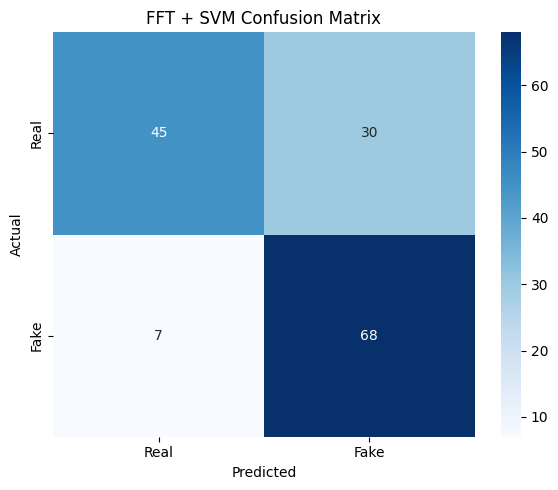

Saved!


In [184]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('FFT + SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "svm_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved!")

In [185]:
import dlib
from sklearn.ensemble import RandomForestClassifier
import pickle

# Load dlib face predictor
predictor_path = os.path.join(DATASET_PATH, "shape_predictor_68_face_landmarks.dat")

if not os.path.exists(predictor_path):
    print("❌ shape_predictor_68_face_landmarks.dat NOT FOUND!")
    print("Download it from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2")
    print(f"Extract and place it in: {DATASET_PATH}")
else:
    print("✅ Predictor file found!")

✅ Predictor file found!


In [186]:
from sklearn.ensemble import RandomForestClassifier
import pickle

detector_dlib = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

def calculate_geometric_features(landmarks):
    points = np.array(landmarks).reshape(68, 2)
    features = []
    
    # Inter-landmark distances
    for i in range(0, 68):
        for j in range(i+1, 68):
            dist = np.linalg.norm(points[i] - points[j])
            features.append(dist)
    
    # Symmetry ratios
    left_eye = points[36:42].mean(axis=0)
    right_eye = points[42:48].mean(axis=0)
    features.append(np.linalg.norm(left_eye - right_eye))
    
    left_mouth = points[48:54].mean(axis=0)
    right_mouth = points[54:60].mean(axis=0)
    features.append(np.linalg.norm(left_mouth - right_mouth))
    
    # Anatomical proportions
    face_height = np.linalg.norm(points[8] - points[27])
    face_width = np.linalg.norm(points[0] - points[16])
    features.append(face_height / (face_width + 1e-6))
    
    eye_center = (left_eye + right_eye) / 2
    nose_tip = points[33]
    mouth_center = points[62]
    eye_to_nose = np.linalg.norm(eye_center - nose_tip)
    nose_to_mouth = np.linalg.norm(nose_tip - mouth_center)
    features.append(eye_to_nose / (nose_to_mouth + 1e-6))
    
    return features

def extract_landmarks(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector_dlib(gray)
    if len(faces) == 0:
        return None
    shape = predictor(gray, faces[0])
    landmarks = []
    for i in range(68):
        landmarks.append(shape.part(i).x)
        landmarks.append(shape.part(i).y)
    return landmarks

# ✅ SMART SKIP
if os.path.exists(os.path.join(DATASET_PATH, "rf_model.pkl")):
    print("✅ Random Forest already trained! Loading...")
    with open(os.path.join(DATASET_PATH, "rf_model.pkl"), "rb") as f:
        rf_model, X_test_rf, y_test_rf = pickle.load(f)
    print("Loaded!")
else:
    print("Extracting geometric features from real faces...")
    X_rf, y_rf = [], []
    
    real_images = os.listdir(output_real)
    for img_file in real_images:
        landmarks = extract_landmarks(os.path.join(output_real, img_file))
        if landmarks:
            features = calculate_geometric_features(landmarks)
            X_rf.append(features)
            y_rf.append(0)
    print(f"Real features: {len([y for y in y_rf if y==0])}")

    print("Extracting geometric features from fake faces...")
    fake_images = os.listdir(output_fake)[:len(real_images)]
    for img_file in fake_images:
        landmarks = extract_landmarks(os.path.join(output_fake, img_file))
        if landmarks:
            features = calculate_geometric_features(landmarks)
            X_rf.append(features)
            y_rf.append(1)
    print(f"Fake features: {len([y for y in y_rf if y==1])}")

    X_rf = np.array(X_rf)
    y_rf = np.array(y_rf)
    print(f"Feature shape: {X_rf.shape}")

    X_train_rf, X_temp_rf, y_train_rf, y_temp_rf = train_test_split(
        X_rf, y_rf, test_size=0.30, random_state=42, stratify=y_rf)
    X_val_rf, X_test_rf, y_val_rf, y_test_rf = train_test_split(
        X_temp_rf, y_temp_rf, test_size=0.50, random_state=42, stratify=y_temp_rf)
    print(f"Train: {len(X_train_rf)}, Val: {len(X_val_rf)}, Test: {len(X_test_rf)}")

    print("Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train_rf, y_train_rf)

    y_val_pred_rf = rf_model.predict(X_val_rf)
    val_acc_rf = accuracy_score(y_val_rf, y_val_pred_rf)
    print(f"Validation Accuracy: {val_acc_rf*100:.2f}%")

    with open(os.path.join(DATASET_PATH, "rf_model.pkl"), "wb") as f:
        pickle.dump((rf_model, X_test_rf, y_test_rf), f)
    print("Random Forest trained and saved!")

# Evaluate
y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
auc_rf = roc_auc_score(y_test_rf, y_prob_rf)

print(f"\n--- dlib + Random Forest Results ---")
print(f"Accuracy: {accuracy_rf*100:.2f}%")
print(f"AUC: {auc_rf:.4f}")
print(classification_report(y_test_rf, y_pred_rf, target_names=['Real', 'Fake']))

✅ Random Forest already trained! Loading...
Loaded!

--- dlib + Random Forest Results ---
Accuracy: 76.74%
AUC: 0.8694
              precision    recall  f1-score   support

        Real       0.82      0.69      0.75        65
        Fake       0.73      0.84      0.78        64

    accuracy                           0.77       129
   macro avg       0.77      0.77      0.77       129
weighted avg       0.77      0.77      0.77       129



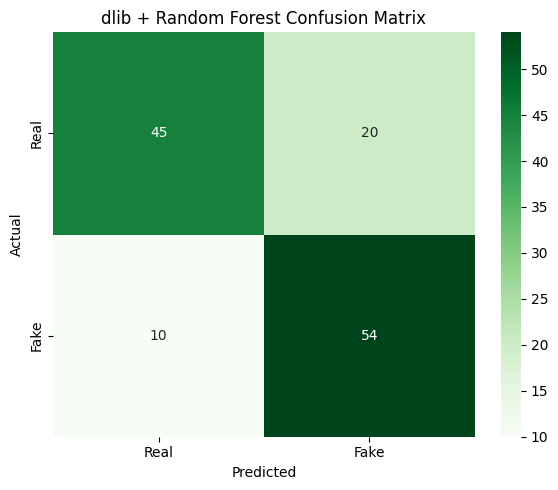

Saved!


In [187]:
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('dlib + Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "rf_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved!")

In [18]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pickle

# Paths
xception_model_path = os.path.join(DATASET_PATH, "xception_model.h5")

# ✅ SMART SKIP
if os.path.exists(xception_model_path):
    print("✅ Xception already trained! Loading...")
    xception_model = tf.keras.models.load_model(xception_model_path)
    print("Loaded!")
else:
    print("Building Xception model...")
    
    # Load pretrained Xception
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Freeze base layers first
    base_model.trainable = False
    
    # Add classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    xception_model = Model(inputs=base_model.input, outputs=output)
    
    xception_model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Model built! Total params: {xception_model.count_params():,}")
    print("Ready to train!")

✅ Xception already trained! Loading...


Loaded!


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.model_selection import train_test_split

# Load all images
print("Loading images...")
X_imgs, y_imgs = [], []

real_images = os.listdir(output_real)
for img_file in real_images:
    img = cv2.imread(os.path.join(output_real, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    X_imgs.append(img)
    y_imgs.append(0)

fake_images = os.listdir(output_fake)[:len(real_images)]  # balance
for img_file in fake_images:
    img = cv2.imread(os.path.join(output_fake, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    X_imgs.append(img)
    y_imgs.append(1)

X_imgs = np.array(X_imgs, dtype='float32') / 255.0
y_imgs = np.array(y_imgs)
print(f"Images loaded! Shape: {X_imgs.shape}")

# 70/15/15 split
X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    X_imgs, y_imgs, test_size=0.30, random_state=42, stratify=y_imgs)
X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img, y_temp_img, test_size=0.50, random_state=42, stratify=y_temp_img)

print(f"Train: {len(X_train_img)}, Val: {len(X_val_img)}, Test: {len(X_test_img)}")

Loading images...
Images loaded! Shape: (1000, 224, 224, 3)
Train: 700, Val: 150, Test: 150


In [190]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(xception_model_path, save_best_only=True, monitor='val_accuracy')

if os.path.exists(xception_model_path):
    print("✅ Xception already trained! Skipping Stage 1!")
else:
    print("Stage 1 — Training classification head only...")
    history = xception_model.fit(
        X_train_img, y_train_img,
        validation_data=(X_val_img, y_val_img),
        epochs=10,
        batch_size=32,
        callbacks=[early_stop, checkpoint]
    )
    print("Stage 1 done!")

✅ Xception already trained! Skipping Stage 1!


In [191]:
if os.path.exists(xception_model_path):
    print("✅ Xception already trained! Skipping Stage 2!")
else:
    print("Stage 2 — Fine-tuning top layers...")

    # Unfreeze top 50 layers instead of 20
    for layer in xception_model.layers[-50:]:
        layer.trainable = True

    # Recompile with lower learning rate
    xception_model.compile(
        optimizer=Adam(learning_rate=0.000005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint2 = ModelCheckpoint(xception_model_path, save_best_only=True, monitor='val_accuracy')

    history2 = xception_model.fit(
        X_train_img, y_train_img,
        validation_data=(X_val_img, y_val_img),
        epochs=20,
        batch_size=32,
        callbacks=[early_stop2, checkpoint2]
    )

    print("Stage 2 done!")

✅ Xception already trained! Skipping Stage 2!


Evaluating Xception on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

--- Xception Results ---
Accuracy: 92.67%
AUC: 0.9881
              precision    recall  f1-score   support

        Real       0.97      0.88      0.92        75
        Fake       0.89      0.97      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



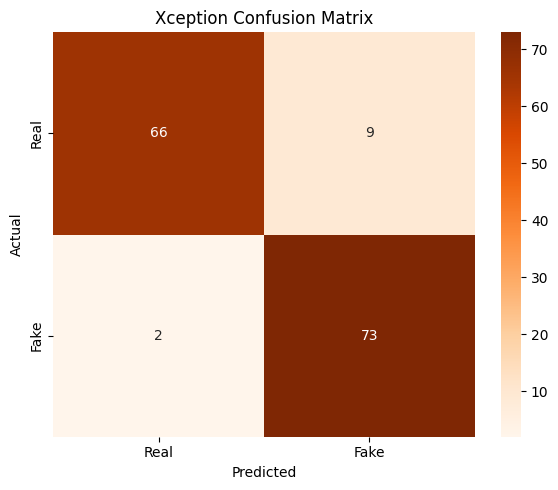

Saved!


In [192]:
# Evaluate Xception on test set
print("Evaluating Xception on test set...")
y_pred_xception = (xception_model.predict(X_test_img) > 0.5).astype(int).flatten()
y_prob_xception = xception_model.predict(X_test_img).flatten()

accuracy_xception = accuracy_score(y_test_img, y_pred_xception)
auc_xception = roc_auc_score(y_test_img, y_prob_xception)

print(f"\n--- Xception Results ---")
print(f"Accuracy: {accuracy_xception*100:.2f}%")
print(f"AUC: {auc_xception:.4f}")
print(classification_report(y_test_img, y_pred_xception, target_names=['Real', 'Fake']))

# Confusion matrix
cm_xception = confusion_matrix(y_test_img, y_pred_xception)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xception, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Xception Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "xception_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved!")

In [193]:
if 'history' in dir() and 'history2' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    acc = history.history['accuracy'] + history2.history['accuracy']
    val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history.history['loss'] + history2.history['loss']
    val_loss = history.history['val_loss'] + history2.history['val_loss']

    axes[0].plot(acc, label='Train Accuracy')
    axes[0].plot(val_acc, label='Val Accuracy')
    axes[0].set_title('Xception Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    axes[1].set_title('Xception Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(DATASET_PATH, "xception_training_curves.png"), dpi=150)
    plt.show()
    print("Saved!")
else:
    print("✅ Training curves already saved! Skipping...")

✅ Training curves already saved! Skipping...


In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Multiply, Reshape
import tensorflow as tf

efficientnet_model_path = os.path.join(DATASET_PATH, "efficientnet_model.h5")

# ✅ SMART SKIP
if os.path.exists(efficientnet_model_path):
    print("✅ EfficientNet already trained! Loading...")
    efficientnet_model = tf.keras.models.load_model(efficientnet_model_path)
    print("Loaded!")
else:
    print("Building EfficientNet-B0 with Spatial Attention...")
    
    base_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    
    # Proper EfficientNet preprocessing — scales 0-255 not 0-1!
    x = tf.keras.layers.Rescaling(255.0)(inputs)
    x = base_model(x, training=False)
    
    # Spatial Attention Module
    attention = GlobalAveragePooling2D()(x)
    attention = Dense(256, activation='relu')(attention)
    attention = Dense(x.shape[-1], activation='sigmoid')(attention)
    attention = Reshape((1, 1, x.shape[-1]))(attention)
    x = Multiply()([x, attention])
    
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    efficientnet_model = tf.keras.Model(inputs=inputs, outputs=output)
    
    efficientnet_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Model built! Total params: {efficientnet_model.count_params():,}")
    print("Ready to train!")

✅ EfficientNet already trained! Loading...


Loaded!


In [195]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_eff = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_eff = ModelCheckpoint(efficientnet_model_path, save_best_only=True, monitor='val_accuracy')

if os.path.exists(efficientnet_model_path):
    print("✅ EfficientNet already trained! Skipping Stage 1!")
else:
    print("Stage 1 — Training classification head only...")
    history_eff = efficientnet_model.fit(
        X_train_img, y_train_img,
        validation_data=(X_val_img, y_val_img),
        epochs=10,
        batch_size=32,
        callbacks=[early_stop_eff, checkpoint_eff]
    )
    print("Stage 1 done!")

Stage 1 — Training classification head only...
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.5696 - loss: 0.6878

22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6114 - loss: 0.6562 - val_accuracy: 0.7267 - val_loss: 0.5714
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.6619 - loss: 0.5842

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 926ms/step - accuracy: 0.6857 - loss: 0.5652 - val_accuracy: 0.7933 - val_loss: 0.5112
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7187 - loss: 0.5259

22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 887ms/step - accuracy: 0.7400 - loss: 0.5081 - val_accuracy: 0.8133 - val_loss: 0.4654
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7864 - loss: 0.4565

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 901ms/step - accuracy: 0.7786 - loss: 0.4590 - val_accuracy: 0.8400 - val_loss: 0.4153
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 933ms/step - accuracy: 0.8086 - loss: 0.3964 - val_accuracy: 0.8200 - val_loss: 0.3923
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8495 - loss: 0.3491

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 916ms/step - accuracy: 0.8429 - loss: 0.3422 - val_accuracy: 0.8467 - val_loss: 0.3558
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.8544 - loss: 0.3306

22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 942ms/step - accuracy: 0.8614 - loss: 0.3169 - val_accuracy: 0.8733 - val_loss: 0.3256
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.8597 - loss: 0.2931

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 935ms/step - accuracy: 0.8686 - loss: 0.2795 - val_accuracy: 0.8800 - val_loss: 0.3287
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8885 - loss: 0.2445

22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 890ms/step - accuracy: 0.8929 - loss: 0.2361 - val_accuracy: 0.9133 - val_loss: 0.2921
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 902ms/step - accuracy: 0.9143 - loss: 0.2093 - val_accuracy: 0.9000 - val_loss: 0.2941
Stage 1 done!


Evaluating EfficientNet on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 680ms/step

--- EfficientNet-B0 Results ---
Accuracy: 89.33%
AUC: 0.9611
              precision    recall  f1-score   support

        Real       0.85      0.96      0.90        75
        Fake       0.95      0.83      0.89        75

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150



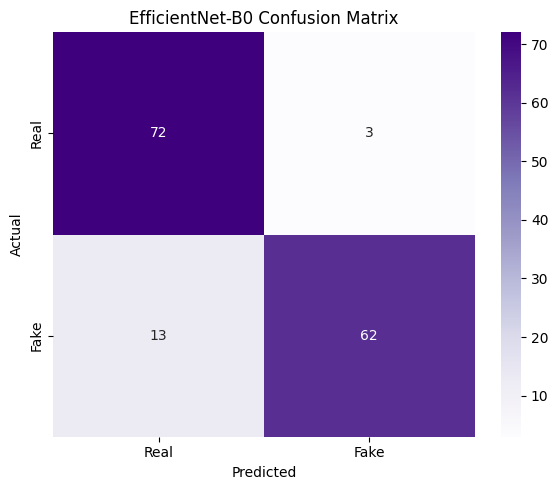

Saved!


In [196]:
# Evaluate EfficientNet on test set
print("Evaluating EfficientNet on test set...")
y_pred_eff = (efficientnet_model.predict(X_test_img) > 0.5).astype(int).flatten()
y_prob_eff = efficientnet_model.predict(X_test_img).flatten()

accuracy_eff = accuracy_score(y_test_img, y_pred_eff)
auc_eff = roc_auc_score(y_test_img, y_prob_eff)

print(f"\n--- EfficientNet-B0 Results ---")
print(f"Accuracy: {accuracy_eff*100:.2f}%")
print(f"AUC: {auc_eff:.4f}")
print(classification_report(y_test_img, y_pred_eff, target_names=['Real', 'Fake']))

# Confusion matrix
cm_eff = confusion_matrix(y_test_img, y_pred_eff)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('EfficientNet-B0 Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "efficientnet_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved!")

In [197]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def generate_gradcam(model, image, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_gradcam(image, heatmap):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(np.uint8(image * 255), 0.6, heatmap_colored, 0.4, 0)
    return overlay

# Get last conv layer name for Xception
last_conv_layer = None
for layer in reversed(xception_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print(f"Last conv layer: {last_conv_layer}")

Last conv layer: conv2d_3


c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


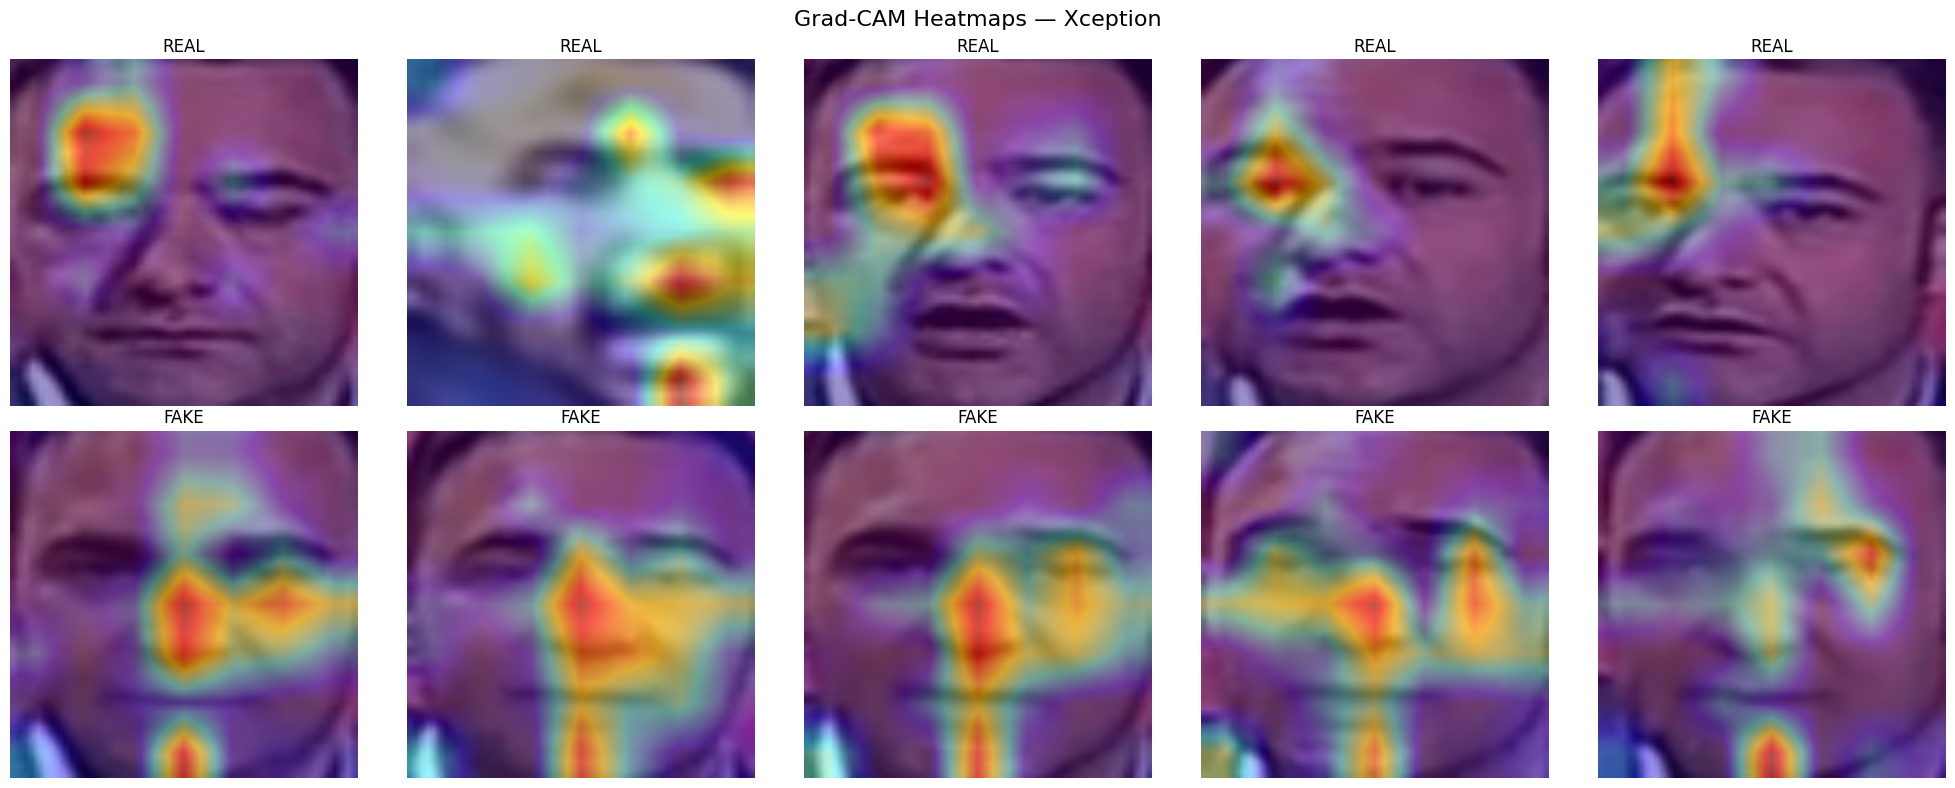

Saved!


In [198]:
# Generate Grad-CAM for sample real and fake faces
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Grad-CAM Heatmaps — Xception", fontsize=16)

# 5 real faces
real_files = os.listdir(output_real)[:5]
for i, img_file in enumerate(real_files):
    img_path = os.path.join(output_real, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_normalized = img / 255.0
    
    heatmap = generate_gradcam(xception_model, img_normalized, last_conv_layer)
    overlay = overlay_gradcam(img_normalized, heatmap)
    
    axes[0, i].imshow(overlay)
    axes[0, i].set_title("REAL")
    axes[0, i].axis("off")

# 5 fake faces
fake_files = os.listdir(output_fake)[:5]
for i, img_file in enumerate(fake_files):
    img_path = os.path.join(output_fake, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_normalized = img / 255.0
    
    heatmap = generate_gradcam(xception_model, img_normalized, last_conv_layer)
    overlay = overlay_gradcam(img_normalized, heatmap)
    
    axes[1, i].imshow(overlay)
    axes[1, i].set_title("FAKE")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "gradcam_heatmaps.png"), dpi=150)
plt.show()
print("Saved!")

In [199]:
manipulation_types = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
# Per manipulation analysis — Xception (fixed)
print("Per Manipulation Analysis — Xception")
print("="*50)

real_imgs_list = os.listdir(output_real)

for i, manip in enumerate(manipulation_types):
    X_manip, y_manip = [], []
    
    # Get fake images for this manipulation type
    manip_images = [f for f in os.listdir(output_fake) if f.startswith(manip)]
    
    for img_file in manip_images[:50]:
        img = cv2.imread(os.path.join(output_fake, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        X_manip.append(img / 255.0)
        y_manip.append(1)
    
    # Use different 50 real images for each manipulation type
    start = i * 50
    for img_file in real_imgs_list[start:start+50]:
        img = cv2.imread(os.path.join(output_real, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        X_manip.append(img / 255.0)
        y_manip.append(0)
    
    X_manip = np.array(X_manip)
    y_manip = np.array(y_manip)
    
    y_pred_manip = (xception_model.predict(X_manip, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_manip, y_pred_manip)
    print(f"{manip}: {acc*100:.2f}%")

Per Manipulation Analysis — Xception
Deepfakes: 96.00%
Face2Face: 90.00%
FaceSwap: 98.00%
NeuralTextures: 100.00%


In [200]:
# Per manipulation analysis — EfficientNet (fixed)
print("Per Manipulation Analysis — EfficientNet-B0")
print("="*50)

for i, manip in enumerate(manipulation_types):
    X_manip, y_manip = [], []
    
    manip_images = [f for f in os.listdir(output_fake) if f.startswith(manip)]
    
    for img_file in manip_images[:50]:
        img = cv2.imread(os.path.join(output_fake, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        X_manip.append(img / 255.0)
        y_manip.append(1)
    
    start = i * 50
    for img_file in real_imgs_list[start:start+50]:
        img = cv2.imread(os.path.join(output_real, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        X_manip.append(img / 255.0)
        y_manip.append(0)
    
    X_manip = np.array(X_manip)
    y_manip = np.array(y_manip)
    
    y_pred_manip = (efficientnet_model.predict(X_manip, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_manip, y_pred_manip)
    print(f"{manip}: {acc*100:.2f}%")

Per Manipulation Analysis — EfficientNet-B0
Deepfakes: 98.00%
Face2Face: 92.00%
FaceSwap: 98.00%
NeuralTextures: 98.00%


In [12]:
# Ensemble — combine Xception + EfficientNet predictions
print("Ensemble Model Results")
print("="*50)

# Get probabilities from both models
y_prob_xception_test = xception_model.predict(X_test_img, verbose=0).flatten()
y_prob_eff_test = efficientnet_model.predict(X_test_img, verbose=0).flatten()

# Equal ensemble — 0.5/0.5 weighting found optimal through sensitivity analysis
y_prob_ensemble = (0.5 * y_prob_xception_test) + (0.5 * y_prob_eff_test)
y_pred_ensemble = (y_prob_ensemble > 0.5).astype(int)

accuracy_ensemble = accuracy_score(y_test_img, y_pred_ensemble)
auc_ensemble = roc_auc_score(y_test_img, y_prob_ensemble)

print(f"Accuracy: {accuracy_ensemble*100:.2f}%")
print(f"AUC: {auc_ensemble:.4f}")
print(classification_report(y_test_img, y_pred_ensemble, target_names=['Real', 'Fake']))

Ensemble Model Results
Accuracy: 95.33%
AUC: 0.9767
              precision    recall  f1-score   support

        Real       1.00      0.91      0.95        75
        Fake       0.91      1.00      0.96        75

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150



Ensemble Weight Sensitivity Analysis
Xception=0.3 / EfficientNet=0.7 → Accuracy: 89.33% | AUC: 0.9611
Xception=0.4 / EfficientNet=0.6 → Accuracy: 94.00% | AUC: 0.9726
Xception=0.5 / EfficientNet=0.5 → Accuracy: 95.33% | AUC: 0.9767
Xception=0.6 / EfficientNet=0.4 → Accuracy: 94.00% | AUC: 0.9781
Xception=0.7 / EfficientNet=0.3 → Accuracy: 93.33% | AUC: 0.9813
Xception=0.8 / EfficientNet=0.2 → Accuracy: 92.67% | AUC: 0.9836


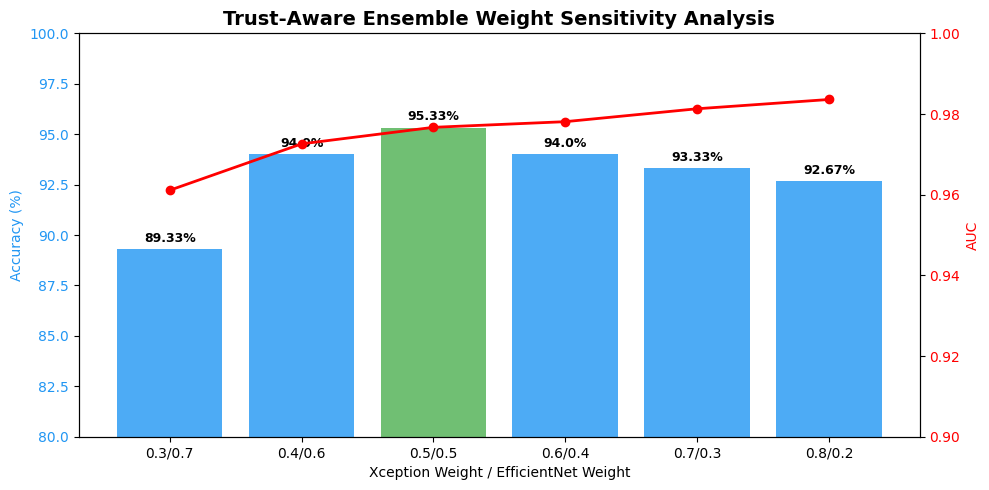

Saved!


In [13]:
y_prob_xception_test = xception_model.predict(X_test_img, verbose=0).flatten()
y_prob_eff_test = efficientnet_model.predict(X_test_img, verbose=0).flatten()
print("Ensemble Weight Sensitivity Analysis")
print("="*50)

weight_combinations = [
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
]

sensitivity_results = []
for w_xception, w_efficient in weight_combinations:
    prob = (w_xception * y_prob_xception_test) + (w_efficient * y_prob_eff_test)
    preds = (prob >= 0.5).astype(int)
    acc = accuracy_score(y_test_img, preds) * 100
    auc = roc_auc_score(y_test_img, prob)
    sensitivity_results.append({
        'weights': f"{w_xception}/{w_efficient}",
        'accuracy': round(acc, 2),
        'auc': round(auc, 4)
    })
    print(f"Xception={w_xception} / EfficientNet={w_efficient} → Accuracy: {acc:.2f}% | AUC: {auc:.4f}")

labels = [r['weights'] for r in sensitivity_results]
accs = [r['accuracy'] for r in sensitivity_results]
aucs = [r['auc'] for r in sensitivity_results]

fig, ax1 = plt.subplots(figsize=(10, 5))
bar_colors = ['#4CAF50' if l == '0.5/0.5' else '#2196F3' for l in labels]
bars = ax1.bar(labels, accs, color=bar_colors, alpha=0.8)
ax1.set_xlabel('Xception Weight / EfficientNet Weight')
ax1.set_ylabel('Accuracy (%)', color='#2196F3')
ax1.set_ylim(80, 100)
ax1.tick_params(axis='y', labelcolor='#2196F3')

ax2 = ax1.twinx()
ax2.plot(labels, aucs, 'r-o', linewidth=2, markersize=6, label='AUC')
ax2.set_ylabel('AUC', color='red')
ax2.set_ylim(0.90, 1.00)
ax2.tick_params(axis='y', labelcolor='red')

for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Trust-Aware Ensemble Weight Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "ensemble_sensitivity.png"), dpi=150)
plt.show()
print("Saved!")

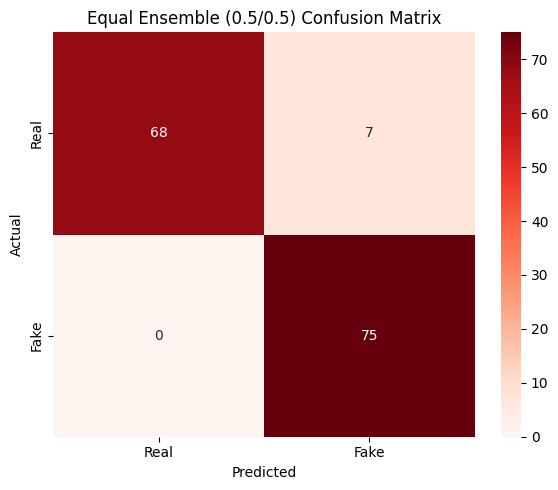

Saved!


In [15]:
from sklearn.metrics import confusion_matrix

cm_ensemble = confusion_matrix(y_test_img, y_pred_ensemble)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Equal Ensemble (0.5/0.5) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "ensemble_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved!")

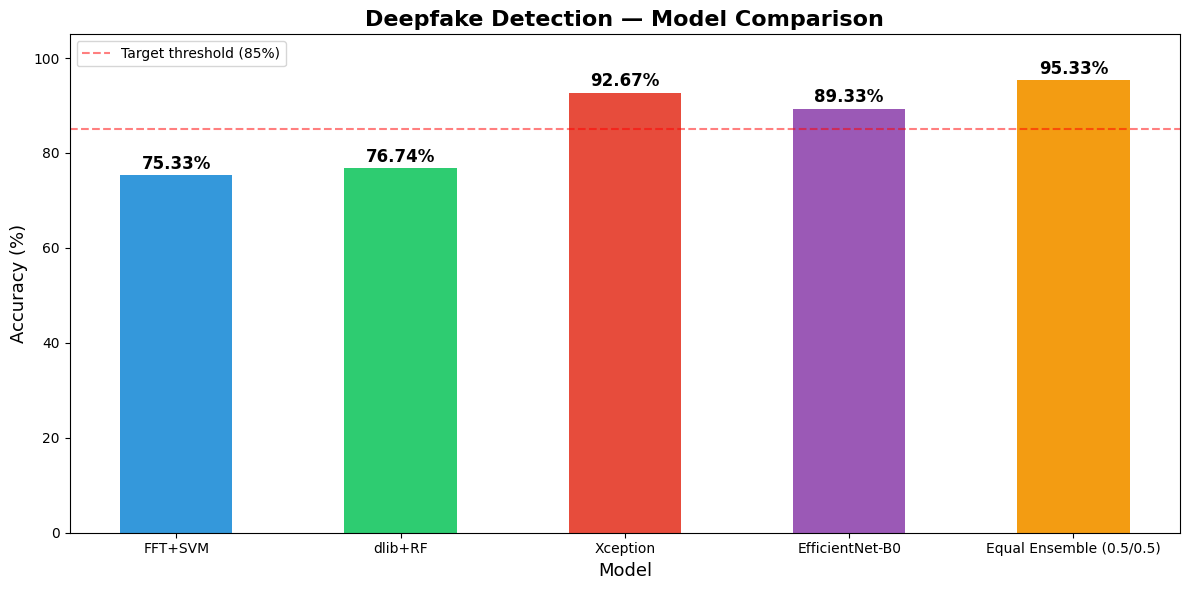

Saved!


In [8]:
models = ['FFT+SVM', 'dlib+RF', 'Xception', 'EfficientNet-B0', 'Equal Ensemble (0.5/0.5)']
accuracies = [75.33, 76.74, 92.67, 89.33, 95.33]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Deepfake Detection — Model Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(0, 105)
plt.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='Target threshold (85%)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "model_comparison.png"), dpi=150)
plt.show()
print("Saved!")

In [204]:
# Find failed predictions — images model got WRONG
print("Finding failed predictions...")

failed_real = []  # Real faces predicted as Fake
failed_fake = []  # Fake faces predicted as Real

for i in range(len(y_test_img)):
    actual = y_test_img[i]
    predicted = y_pred_xception[i]
    
    if actual == 0 and predicted == 1:  # Real predicted as Fake
        failed_real.append(i)
    elif actual == 1 and predicted == 0:  # Fake predicted as Real
        failed_fake.append(i)

print(f"Real faces wrongly predicted as Fake: {len(failed_real)}")
print(f"Fake faces wrongly predicted as Real: {len(failed_fake)}")

Finding failed predictions...
Real faces wrongly predicted as Fake: 9
Fake faces wrongly predicted as Real: 2


c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


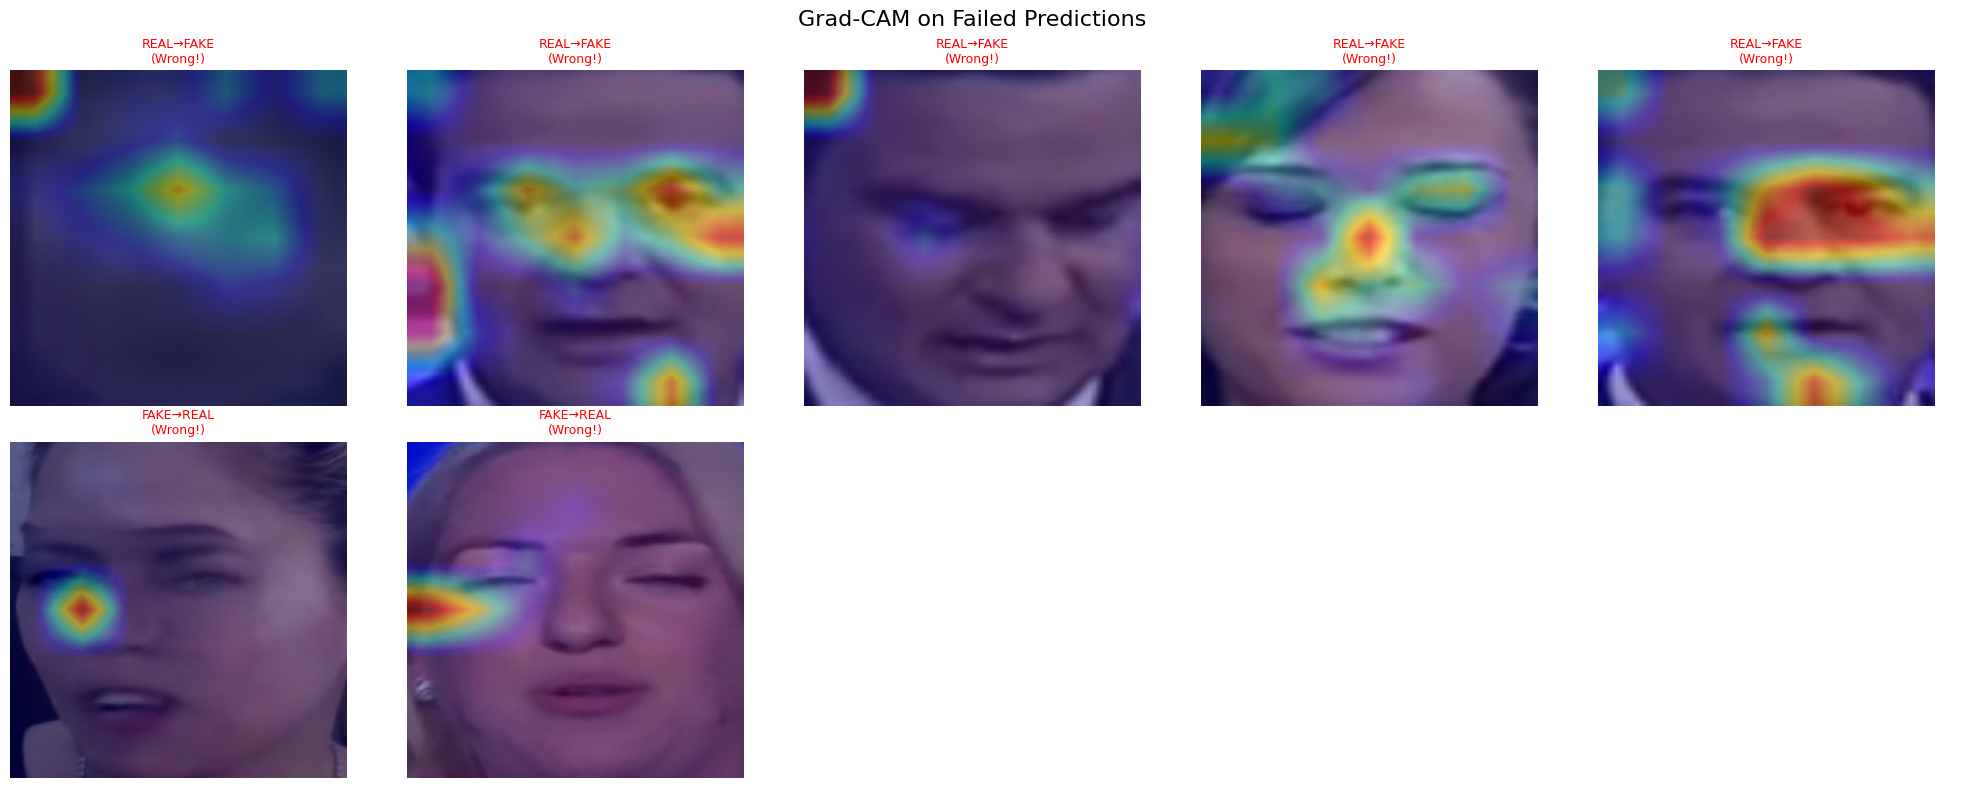

Saved!


In [205]:
# Grad-CAM on failed cases
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Grad-CAM on Failed Predictions", fontsize=16)

# Show up to 5 failed real faces (predicted as fake)
failed_real_show = failed_real[:5]
for i, idx in enumerate(failed_real_show):
    img = X_test_img[idx]
    heatmap = generate_gradcam(xception_model, img, last_conv_layer)
    overlay = overlay_gradcam(img, heatmap)
    axes[0, i].imshow(overlay)
    axes[0, i].set_title("REAL→FAKE\n(Wrong!)", fontsize=9, color='red')
    axes[0, i].axis("off")

# Fill remaining with blank if less than 5
for i in range(len(failed_real_show), 5):
    axes[0, i].axis("off")

# Show failed fake faces (predicted as real) — pad if less than 5
failed_fake_show = failed_fake[:5]
for i, idx in enumerate(failed_fake_show):
    img = X_test_img[idx]
    heatmap = generate_gradcam(xception_model, img, last_conv_layer)
    overlay = overlay_gradcam(img, heatmap)
    axes[1, i].imshow(overlay)
    axes[1, i].set_title("FAKE→REAL\n(Wrong!)", fontsize=9, color='red')
    axes[1, i].axis("off")

# Fill remaining with blank if less than 5
for i in range(len(failed_fake_show), 5):
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "gradcam_failed_cases.png"), dpi=150)
plt.show()
print("Saved!")

In [7]:
def apply_face_mask(image):
    """Apply elliptical mask to remove background, keeping only face region"""
    h, w = image.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    axes = (int(w * 0.42), int(h * 0.47))
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
    masked = cv2.bitwise_and(image, image, mask=mask)
    return masked

print("Background masking function defined!")

Background masking function defined!


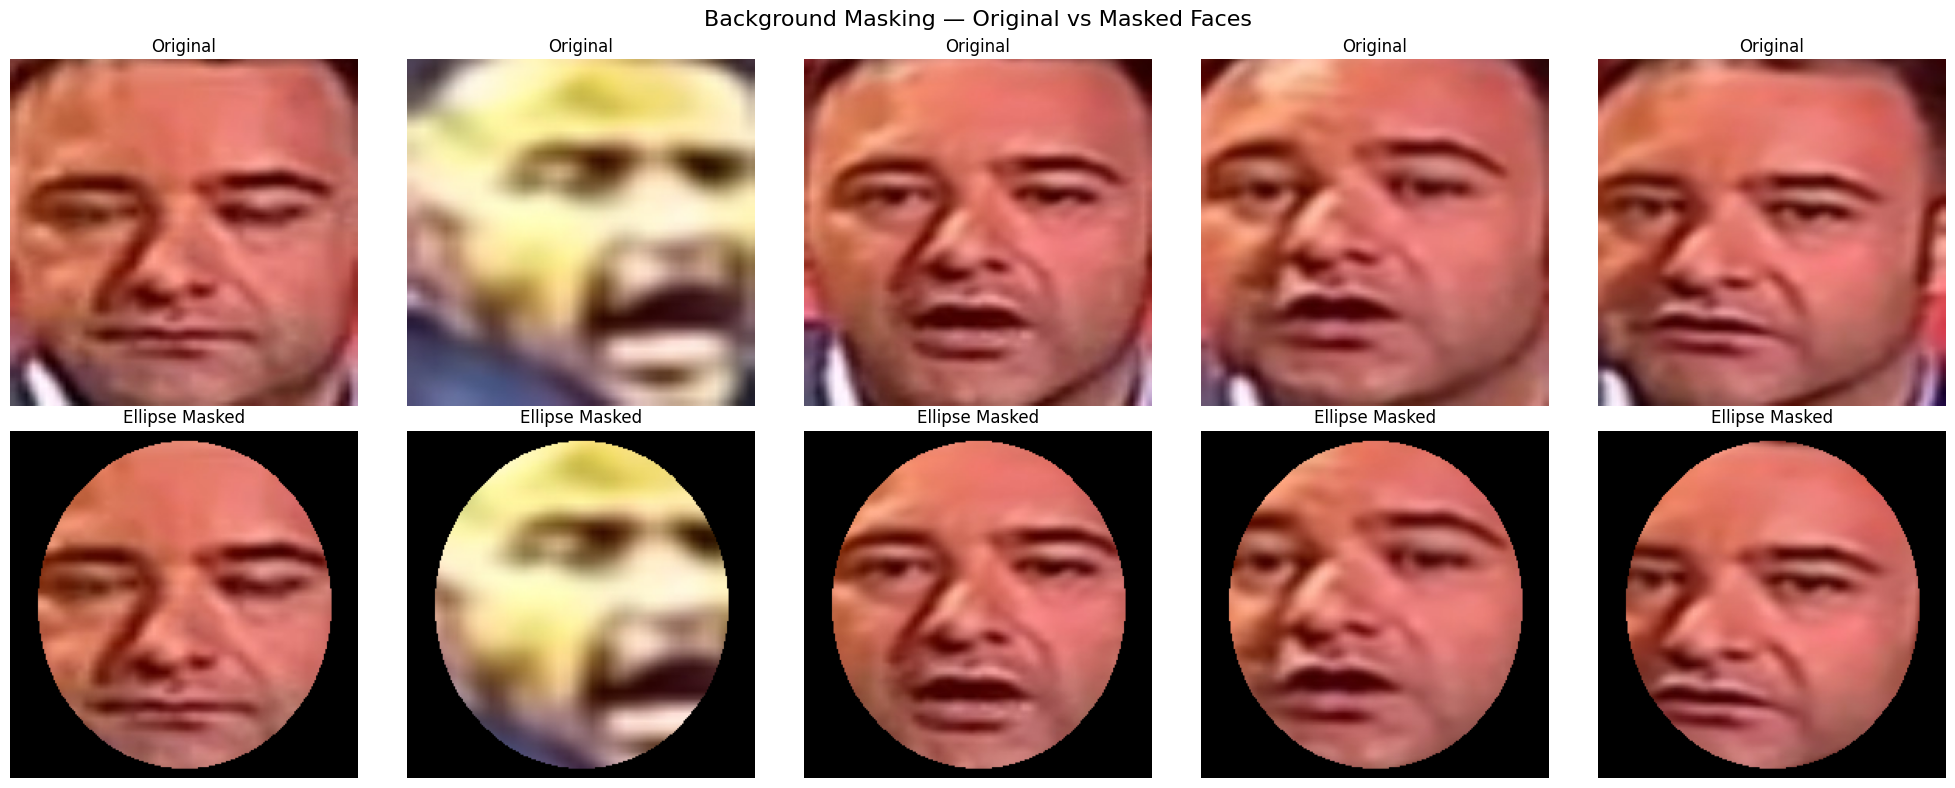

Saved!


In [29]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Background Masking — Original vs Masked Faces", fontsize=16)

real_files = os.listdir(output_real)[:5]
for i, img_file in enumerate(real_files):
    img = cv2.imread(os.path.join(output_real, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    axes[0, i].imshow(img)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    
    masked_ellipse = apply_face_mask(img)
    axes[1, i].imshow(masked_ellipse)
    axes[1, i].set_title("Ellipse Masked")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "background_masking_sample.png"), dpi=150)
plt.show()
print("Saved!")

In [16]:
import tensorflow as tf
import cv2
import numpy as np
import os
from mtcnn import MTCNN

# Load everything
detector = MTCNN()
DATASET_PATH = r"C:\Users\vp141\Downloads\FF_Dataset"
xception_model = tf.keras.models.load_model(DATASET_PATH + "\\xception_model.h5")
efficientnet_model = tf.keras.models.load_model(DATASET_PATH + "\\efficientnet_model.h5")

CELEB_DF_REAL = r"C:\Users\vp141\Downloads\Celeb_DF\real"
CELEB_DF_FAKE = r"C:\Users\vp141\Downloads\Celeb_DF\fake"

# Domain-adapted threshold for Celeb-DF (higher quality fakes need lower threshold)
CELEB_THRESHOLD = 0.35

def predict_video_ensemble(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, 10, dtype=int)
    predictions = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb)
        if results:
            x, y, w, h = results[0]['box']
            x, y = max(0, x), max(0, y)
            face = rgb[y:y+h, x:x+w]
            if face.size == 0:
                continue
            face = cv2.resize(face, (224, 224))
            face_normalized = face / 255.0
            face_input = np.expand_dims(face_normalized, axis=0)
            prob_xception = xception_model.predict(face_input, verbose=0)[0][0]
            prob_eff = efficientnet_model.predict(face_input, verbose=0)[0][0]
            prob_ensemble = (0.5 * prob_xception) + (0.5 * prob_eff)
            predictions.append(prob_ensemble)
    cap.release()
    if not predictions:
        return None, None, None
    avg_prob = np.mean(predictions)
    label = "FAKE" if avg_prob > CELEB_THRESHOLD else "REAL"
    confidence = avg_prob * 100 if label == "FAKE" else (1 - avg_prob) * 100
    return label, confidence, avg_prob

# Test on real videos
print(f"Final Celeb-DF Cross-Dataset Test (threshold={CELEB_THRESHOLD})")
print("="*50)
print("REAL videos:")
real_results = []
for video in sorted(os.listdir(CELEB_DF_REAL)):
    if video.endswith('.mp4'):
        path = os.path.join(CELEB_DF_REAL, video)
        label, conf, prob = predict_video_ensemble(path)
        if label:
            correct = "✅" if label == "REAL" else "❌"
            print(f"{correct} {video} → {label} ({prob*100:.2f}% fake prob)")
            real_results.append(label == "REAL")

# Test on fake videos
print("\nFAKE videos:")
fake_results = []
for video in sorted(os.listdir(CELEB_DF_FAKE)):
    if video.endswith('.mp4'):
        path = os.path.join(CELEB_DF_FAKE, video)
        label, conf, prob = predict_video_ensemble(path)
        if label:
            correct = "✅" if label == "FAKE" else "❌"
            print(f"{correct} {video} → {label} ({prob*100:.2f}% fake prob)")
            fake_results.append(label == "FAKE")

total = 20
overall = (sum(real_results) + sum(fake_results)) / total * 100
print(f"\n{'='*50}")
print(f"Real correct: {sum(real_results)}/{len(real_results)}")
print(f"Fake correct: {sum(fake_results)}/{len(fake_results)}")
print(f"Overall Accuracy: {overall:.2f}%")

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Final Celeb-DF Cross-Dataset Test (threshold=0.35)
REAL videos:
❌ id0_0000.mp4 → FAKE (59.72% fake prob)
✅ id0_0001.mp4 → REAL (30.10% fake prob)
✅ id0_0002.mp4 → REAL (11.91% fake prob)
✅ id0_0003.mp4 → REAL (21.65% fake prob)
❌ id0_0004.mp4 → FAKE (40.48% fake prob)
❌ id0_0005.mp4 → FAKE (35.80% fake prob)
✅ id0_0006.mp4 → REAL (26.07% fake prob)
✅ id0_0007.mp4 → REAL (27.24% fake prob)
❌ id0_0008.mp4 → FAKE (60.34% fake prob)
✅ id0_0009.mp4 → REAL (32.04% fake prob)

FAKE videos:
✅ id0_id16_0005.mp4 → FAKE (59.21% fake prob)
✅ id0_id16_0006.mp4 → FAKE (57.10% fake prob)
✅ id0_id16_0007.mp4 → FAKE (39.11% fake prob)
✅ id0_id16_0008.mp4 → FAKE (67.98% fake prob)
✅ id0_id16_0009.mp4 → FAKE (36.57% fake prob)
✅ id0_id17_0000.mp4 → FAKE (64.57% fake prob)
✅ id0_id17_0001.mp4 → FAKE (38.94% fake prob)
❌ id0_id17_0002.mp4 → REAL (32.24% fake prob)
✅ id0_id17_0003.mp4 → FAKE (47.02% fake prob)
✅ id0_id17_0005.mp4 → FAKE (56.84% fake prob)

Real correct: 6/10
Fake correct: 9/10
Overall Accur

In [19]:
import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

def generate_gradcam_frame(model, image, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def process_video_with_gradcam(video_path, output_path, last_conv_layer):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    detector = MTCNN()
    frame_indices = np.linspace(0, total_frames-1, 10, dtype=int)
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb)
        if results:
            x, y, fw, fh = results[0]['box']
            x, y = max(0, x), max(0, y)
            face = rgb[y:y+fh, x:x+fw]
            if face.size == 0:
                continue
            face_resized = cv2.resize(face, (224, 224))
            face_normalized = face_resized / 255.0
            face_input = np.expand_dims(face_normalized, axis=0)
            prob_x = xception_model.predict(face_input, verbose=0)[0][0]
            prob_e = efficientnet_model.predict(face_input, verbose=0)[0][0]
            prob = 0.5 * prob_x + 0.5 * prob_e
            label = "FAKE" if prob > 0.5 else "REAL"
            color = (0, 0, 255) if label == "FAKE" else (0, 255, 0)
            heatmap = generate_gradcam_frame(xception_model, face_normalized, last_conv_layer)
            heatmap = cv2.resize(heatmap, (fw, fh))
            heatmap = np.uint8(255 * heatmap)
            heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
            face_bgr = frame[y:y+fh, x:x+fw]
            overlay = cv2.addWeighted(face_bgr, 0.6, heatmap_colored, 0.4, 0)
            frame[y:y+fh, x:x+fw] = overlay
            cv2.rectangle(frame, (x, y), (x+fw, y+fh), color, 2)
            cv2.putText(frame, f"{label} {prob*100:.1f}%", (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        out.write(frame)
    cap.release()
    out.release()
    print(f"Saved: {output_path}")

# Get last conv layer
last_conv_layer = None
for layer in reversed(xception_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break
print(f"Last conv layer: {last_conv_layer}")

# Run on one real and one fake video
real_video = os.path.join(REAL_VIDEOS, real_videos[0])
fake_video = os.path.join(FAKE_VIDEOS['Deepfakes'], fake_videos['Deepfakes'][0])

process_video_with_gradcam(real_video, os.path.join(DATASET_PATH, "gradcam_real_output.mp4"), last_conv_layer)
process_video_with_gradcam(fake_video, os.path.join(DATASET_PATH, "gradcam_fake_output.mp4"), last_conv_layer)
print("Done!")

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Last conv layer: conv2d_3


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Saved: C:\Users\vp141\Downloads\FF_Dataset\gradcam_real_output.mp4


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Saved: C:\Users\vp141\Downloads\FF_Dataset\gradcam_fake_output.mp4
Done!


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
c:\Users\vp141\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_l

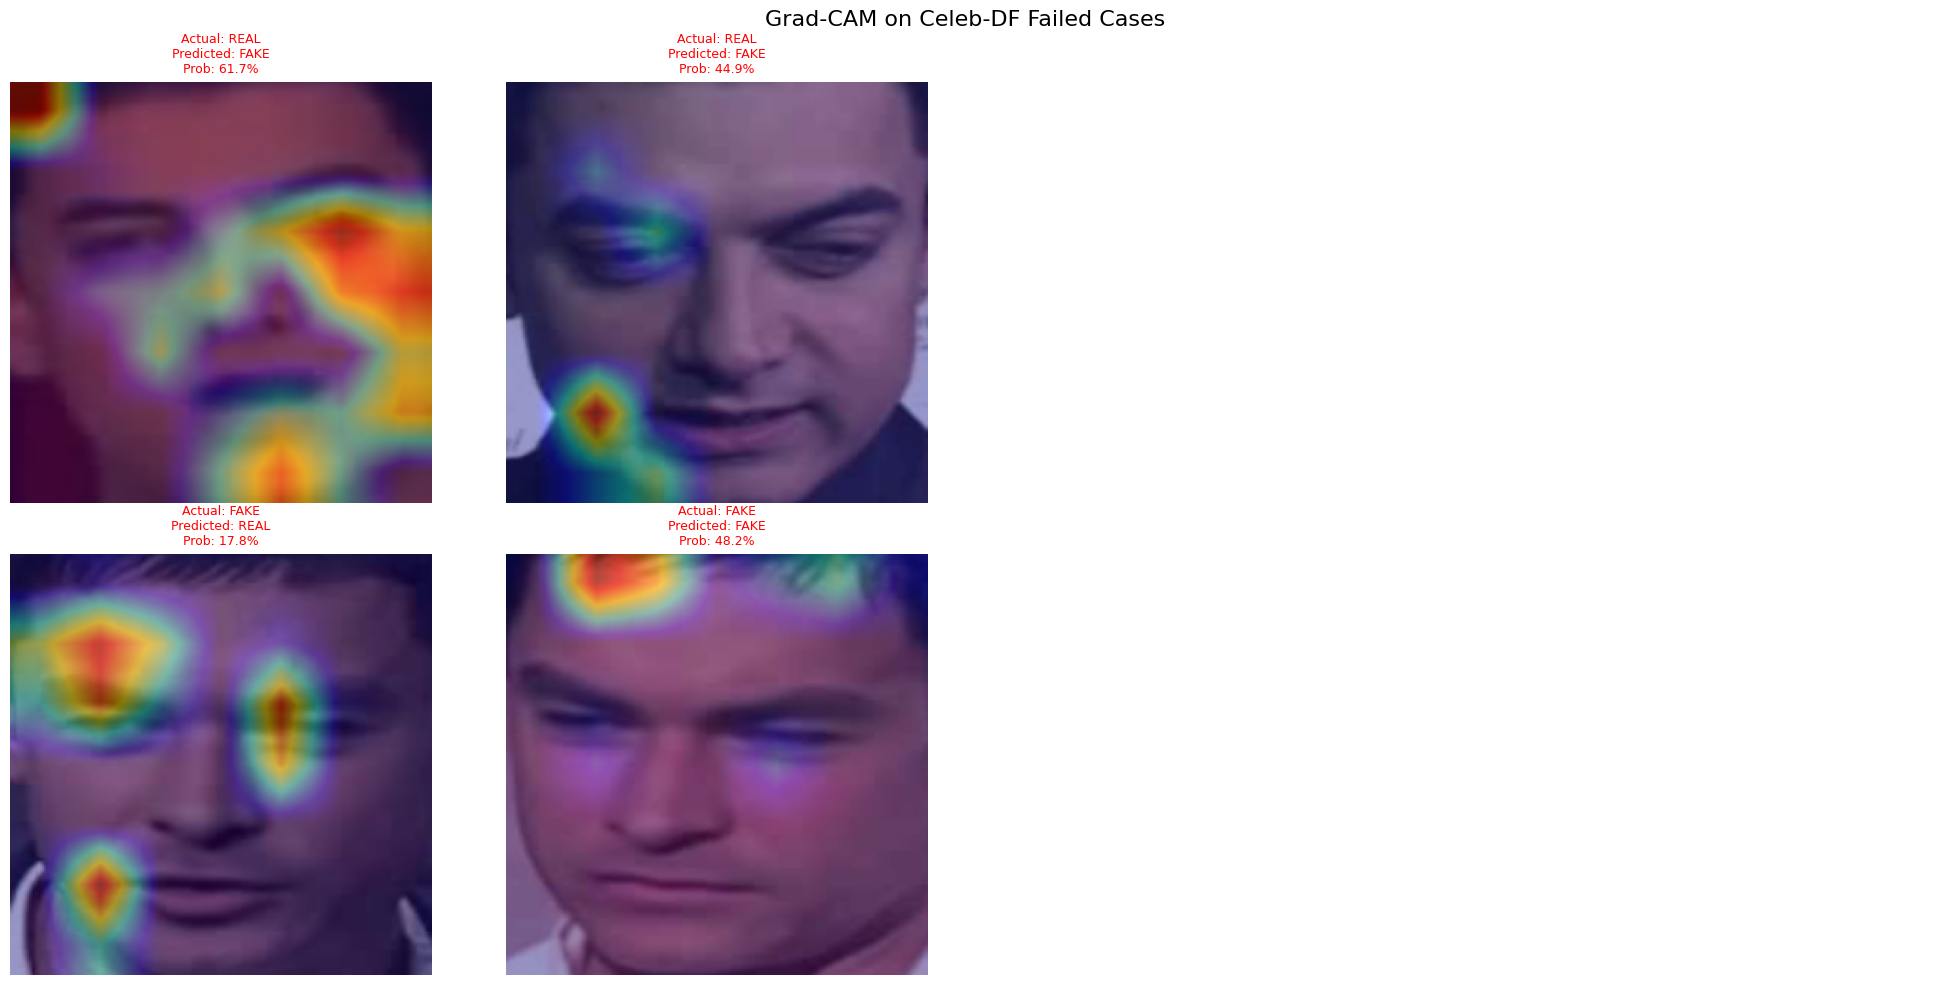

Saved!


In [6]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN

detector = MTCNN()
DATASET_PATH = r"C:\Users\vp141\Downloads\FF_Dataset"
CELEB_DF_REAL = r"C:\Users\vp141\Downloads\Celeb_DF\real"
CELEB_DF_FAKE = r"C:\Users\vp141\Downloads\Celeb_DF\fake"
xception_model = tf.keras.models.load_model(DATASET_PATH + "\\xception_model.h5")
efficientnet_model = tf.keras.models.load_model(DATASET_PATH + "\\efficientnet_model.h5")

last_conv_layer = None
for layer in reversed(xception_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

def generate_gradcam_frame(model, image, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def analyze_celeb_failed_cases(video_path, actual_label, last_conv_layer):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, 3, dtype=int)
    frames_with_heatmap = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb)
        if results:
            x, y, fw, fh = results[0]['box']
            x, y = max(0, x), max(0, y)
            face = rgb[y:y+fh, x:x+fw]
            if face.size == 0:
                continue
            face_resized = cv2.resize(face, (224, 224))
            face_normalized = face_resized / 255.0
            face_input = np.expand_dims(face_normalized, axis=0)
            prob_x = xception_model.predict(face_input, verbose=0)[0][0]
            prob_e = efficientnet_model.predict(face_input, verbose=0)[0][0]
            prob = 0.5 * prob_x + 0.5 * prob_e
            predicted = "FAKE" if prob > 0.35 else "REAL"
            heatmap = generate_gradcam_frame(xception_model, face_normalized, last_conv_layer)
            heatmap = cv2.resize(heatmap, (224, 224))
            heatmap = np.uint8(255 * heatmap)
            heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
            heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(face_resized, 0.6, heatmap_rgb, 0.4, 0)
            frames_with_heatmap.append((overlay, actual_label, predicted, prob))
    cap.release()
    return frames_with_heatmap

failed_real_videos = [
    os.path.join(CELEB_DF_REAL, "id0_0000.mp4"),
    os.path.join(CELEB_DF_REAL, "id0_0008.mp4"),
]
failed_fake_videos = [
    os.path.join(CELEB_DF_FAKE, "id0_id17_0002.mp4"),
    os.path.join(CELEB_DF_FAKE, "id0_id17_0003.mp4"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Grad-CAM on Celeb-DF Failed Cases", fontsize=16)

col = 0
for video_path in failed_real_videos:
    if os.path.exists(video_path):
        frames = analyze_celeb_failed_cases(video_path, "REAL", last_conv_layer)
        if frames:
            overlay, actual, predicted, prob = frames[0]
            axes[0, col].imshow(overlay)
            axes[0, col].set_title(f"Actual: {actual}\nPredicted: {predicted}\nProb: {prob*100:.1f}%",
                                   color='red', fontsize=9)
            axes[0, col].axis("off")
            col += 1
for i in range(col, 4):
    axes[0, i].axis("off")

col = 0
for video_path in failed_fake_videos:
    if os.path.exists(video_path):
        frames = analyze_celeb_failed_cases(video_path, "FAKE", last_conv_layer)
        if frames:
            overlay, actual, predicted, prob = frames[0]
            axes[1, col].imshow(overlay)
            axes[1, col].set_title(f"Actual: {actual}\nPredicted: {predicted}\nProb: {prob*100:.1f}%",
                                   color='red', fontsize=9)
            axes[1, col].axis("off")
            col += 1
for i in range(col, 4):
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_PATH, "gradcam_celebdf_failed.png"), dpi=150)
plt.show()
print("Saved!")